Indexing volumes...
Indexing volumes...
Epoch 1/15
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 382s 333ms/step - accuracy: 0.7370 - auc: 0.8032 - loss: 0.6059 - val_accuracy: 0.8842 - val_auc: 0.9533 - val_loss: 0.2649 - learning_rate: 1.0000e-04
Epoch 2/15
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 215s 192ms/step - accuracy: 0.8908 - auc: 0.9389 - loss: 0.2987 - val_accuracy: 0.8684 - val_auc: 0.9520 - val_loss: 0.3434 - learning_rate: 1.0000e-04
Epoch 3/15
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 203s 182ms/step - accuracy: 0.8925 - auc: 0.9474 - loss: 0.2833 - val_accuracy: 0.8842 - val_auc: 0.9572 - val_loss: 0.3076 - learning_rate: 1.0000e-04
Epoch 4/15
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 194s 173ms/step - accuracy: 0.9026 - auc: 0.9477 - loss: 0.2660 - val_accuracy: 0.8719 - val_auc: 0.9725 - val_loss: 0.2890 - learning_rate: 1.0000e-04
Epoch 5/15
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 194s 173ms/step - accuracy: 0.9338 - auc: 0.9669 - loss: 0.1975 - val_accuracy: 0.9263 - val_auc: 0.9724 - val_loss: 0.2079 - learning_rate: 3

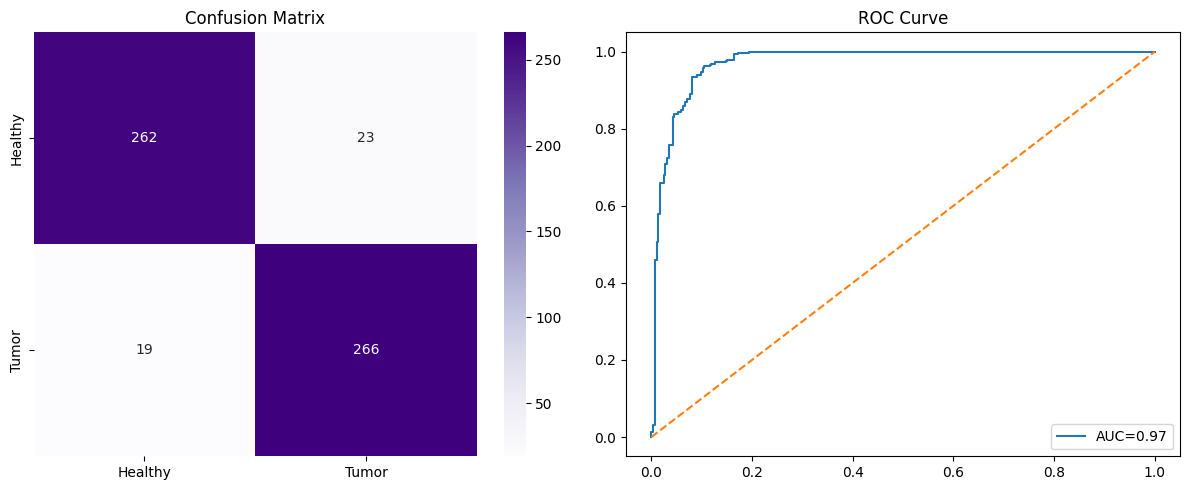

              precision    recall  f1-score   support

         0.0       0.93      0.92      0.93       285
         1.0       0.92      0.93      0.93       285

    accuracy                           0.93       570
   macro avg       0.93      0.93      0.93       570
weighted avg       0.93      0.93      0.93       570

AUC: 0.9719790704832256
✅ Model saved as panda_net_pancreas_clean.h5


In [5]:
# ================= INSTALL =================
!pip install nibabel tensorflow seaborn -q

# ================= IMPORTS =================
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import Sequence
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# ================= CONFIG =================
PATCH_SIZE = 64
BATCH_SIZE = 2
EPOCHS = 15
BASE_PATH = "/kaggle/input/datasets/rksrank1/pancreatic-cancer/Task07_Pancreas"
IMAGE_DIR = os.path.join(BASE_PATH, "imagesTr")
MASK_DIR = os.path.join(BASE_PATH, "labelsTr")

# ================= DATA SEQUENCE =================
class Pancreas3DPatchSequence(Sequence):
    def __init__(self, patient_files, batch_size=BATCH_SIZE, is_training=True):
        self.patient_files = patient_files
        self.batch_size = batch_size
        self.is_training = is_training
        self.samples = self._prepare_samples()

    def _prepare_samples(self):
        samples = []
        print(f"Indexing volumes...")

        for file in self.patient_files:
            # skip hidden/macOS files
            if file.startswith(".") or file.startswith("._"):
                continue

            mask_path = os.path.join(MASK_DIR, file)
            img_path = os.path.join(IMAGE_DIR, file)

            if not os.path.exists(mask_path) or not os.path.exists(img_path):
                continue

            try:
                mask = nib.load(mask_path).get_fdata()
            except Exception as e:
                print(f"Skipping file {file}: {e}")
                continue

            tumor_indices = np.argwhere(mask == 2)

            if len(tumor_indices) > 0:
                # multiple tumor samples
                for _ in range(5):
                    idx = np.random.randint(len(tumor_indices))
                    samples.append((file, tumor_indices[idx], 1))

                # multiple healthy samples
                h, w, d = mask.shape
                for _ in range(5):
                    while True:
                        pt = [np.random.randint(0,h), np.random.randint(0,w), np.random.randint(0,d)]
                        if mask[tuple(pt)] == 0:
                            samples.append((file, pt, 0))
                            break

        np.random.shuffle(samples)
        return samples

    def __len__(self):
        return int(np.ceil(len(self.samples)/self.batch_size))

    def __getitem__(self, idx):
        batch = self.samples[idx*self.batch_size:(idx+1)*self.batch_size]
        X, y = [], []

        for file, center, label in batch:
            img_path = os.path.join(IMAGE_DIR, file)
            img = nib.load(img_path).get_fdata()

            z, y_c, x = [int(c) for c in center]

            z_s = max(0, z-PATCH_SIZE//2)
            y_s = max(0, y_c-PATCH_SIZE//2)
            x_s = max(0, x-PATCH_SIZE//2)

            patch = img[z_s:z_s+PATCH_SIZE, y_s:y_s+PATCH_SIZE, x_s:x_s+PATCH_SIZE]

            # pad if smaller
            if patch.shape != (PATCH_SIZE, PATCH_SIZE, PATCH_SIZE):
                pad_dims = [(0, PATCH_SIZE - s) for s in patch.shape]
                patch = np.pad(patch, pad_dims, mode='constant')

            # normalize
            patch = np.clip(patch, -100, 200)
            patch = (patch + 100)/300.0

            # augmentation
            if self.is_training:
                if np.random.rand() < 0.5: patch = np.flip(patch, 0)
                if np.random.rand() < 0.5: patch = np.flip(patch, 1)
                if np.random.rand() < 0.5: patch = np.flip(patch, 2)

            X.append(patch[..., np.newaxis])
            y.append(label)

        return np.array(X, dtype='float32'), np.array(y, dtype='float32')

# ================= MODEL =================
def residual_block(x, filters):
    shortcut = x
    if x.shape[-1] != filters:
        shortcut = Conv3D(filters, 1, padding='same')(shortcut)

    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv3D(filters, 3, padding='same')(x)

    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv3D(filters, 3, padding='same')(x)

    return Add()([shortcut, x])

def build_model():
    inp = Input((PATCH_SIZE, PATCH_SIZE, PATCH_SIZE, 1))

    x = Conv3D(32, 3, strides=2, padding='same')(inp)
    x = residual_block(x, 32)
    x = residual_block(x, 32)

    x = Conv3D(64, 3, strides=2, padding='same')(x)
    x = residual_block(x, 64)
    x = residual_block(x, 64)

    x = GlobalAveragePooling3D()(x)
    x = Dropout(0.5)(x)

    out = Dense(1, activation='sigmoid')(x)

    model = Model(inp, out)
    model.compile(
        optimizer=Adam(1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

# ================= LOAD FILES =================
files = sorted([
    f for f in os.listdir(IMAGE_DIR)
    if (f.endswith(".nii") or f.endswith(".nii.gz")) and not f.startswith(".") and not f.startswith("._")
])

train_files, test_files = train_test_split(files, test_size=0.2, random_state=42)

train_seq = Pancreas3DPatchSequence(train_files)
test_seq = Pancreas3DPatchSequence(test_files, is_training=False)

# ================= TRAIN =================
model = build_model()

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.3),
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
]

model.fit(train_seq, validation_data=test_seq, epochs=EPOCHS, callbacks=callbacks)

# ================= EVALUATION =================
y_true, y_prob = [], []
for i in range(len(test_seq)):
    x, y = test_seq[i]
    p = model.predict(x, verbose=0)
    y_true.extend(y)
    y_prob.extend(p.flatten())

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = (y_prob > 0.5).astype(int)

# plots
cm = confusion_matrix(y_true, y_pred)
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Healthy','Tumor'], yticklabels=['Healthy','Tumor'])
plt.title("Confusion Matrix")

plt.subplot(1,2,2)
plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred))
print("AUC:", roc_auc)

# ================= SAVE MODEL =================
model.save("panda_net_pancreas_clean.h5")
print("✅ Model saved as panda_net_pancreas_clean.h5")